# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [16]:
class Card:
    suits  = ["Clubs", "Diamonds", "Hearts", "Spades"]
    values = [2, 3, 4, 5, 6, 7, 8, 9, 10, "Jack", "Queen", "King", "Ace"]
 
    def __init__(self, suit, value):
        self.__suit  = suit
        self.__value = value
        self.__is_shuffle = False
 
    def suit(self):
        return self.__suit
 
    def value(self):
        return self.__value
 
    def numerical_value(self):
        # ace starts at 1; hand_value upgrades it to 11 whenits safe
        if self.__value == "Ace":
            return 1
        elif self.__value in ["Jack", "Queen", "King"]:
            return 10
        else:
            return self.__value
 
    def is_shuffle_card(self):
        return self.__is_shuffle
 
    def set_shuffle(self):
        self.__is_shuffle = True
 
    def __str__(self):
        if self.__is_shuffle:
            return "Shuffle Card"
        return str(self.__value) + " of " + self.__suit
 
 
class Deck:
    def __init__(self, num_decks=6):
        self.__cards         = list()
        self.__num_decks     = num_decks
        self.__needs_shuffle = False
 
        for _ in range(num_decks):
            self.__add_deck()
 
        # plastic card placed in deck which triggers reshuffle when coming out
        plastic = Card("None", 0)
        plastic.set_shuffle()
        self.__cards.append(plastic)
 
    def __add_deck(self):
        for suit in Card.suits:
            for value in Card.values:
                self.__cards.append(Card(suit, value))
 
    def shuffle(self):
        random.shuffle(self.__cards)
        self.__needs_shuffle = False
 
    def deal(self):
        # rebuilding the deck if empty or plastic card were hit 
        if len(self.__cards) == 0 or self.__needs_shuffle:
            self.__cards = list()
            for _ in range(self.__num_decks):
                self.__add_deck()
            plastic = Card("None", 0)
            plastic.set_shuffle()
            self.__cards.append(plastic)
            self.shuffle()
 
        card = self.__cards.pop()
 
        if card.is_shuffle_card():
            self.__needs_shuffle = True
            if len(self.__cards) == 0:
                self.__cards = list()
                for _ in range(self.__num_decks):
                    self.__add_deck()
                plastic = Card("None", 0)
                plastic.set_shuffle()
                self.__cards.append(plastic)
                self.shuffle()
            card = self.__cards.pop()
 
        return card
 
 
def hand_value(hand):
    total  = sum(c.numerical_value() for c in hand)
    n_aces = sum(1 for c in hand if c.value() == "Ace")
 
    if n_aces == 0:
        return total
    # promote one ace from 1 to 11 only if it wont bust the hand
    if total + 10 <= 21:
        return total + 10
    return total
 
 
# TESTING
test_deck = Deck(6)
test_deck.shuffle()
 
print("Dealing 8 cards from a fresh shuffled deck:")
for _ in range(8):
    print(test_deck.deal())
 
print()
hand_a = [Card("Spades", 10), Card("Clubs", "Ace")]
print([str(c) for c in hand_a], "=", hand_value(hand_a))   # should give21
 
hand_b = [Card("Hearts", 9), Card("Diamonds", 5), Card("Clubs", "Ace")]
print([str(c) for c in hand_b], "=", hand_value(hand_b))   # should give 15
 
hand_c = [Card("Spades", "Ace"), Card("Hearts", "Ace"), Card("Diamonds", 9)]
print([str(c) for c in hand_c], "=", hand_value(hand_c))   # sould give 21

Dealing 8 cards from a fresh shuffled deck:
Queen of Hearts
5 of Hearts
2 of Diamonds
Jack of Diamonds
4 of Spades
Queen of Spades
4 of Spades
King of Hearts

['10 of Spades', 'Ace of Clubs'] = 21
['9 of Hearts', '5 of Diamonds', 'Ace of Clubs'] = 15
['Ace of Spades', 'Ace of Hearts', '9 of Diamonds'] = 21


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

In [17]:
# UML class diagram Provided in separate pdf file

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [20]:
class Player:
    # base class= all player types extend this
 
    def __init__(self, name, chips=100):
        self.__name  = name
        self.__chips = chips
        self.__hand  = list()
 
    def name(self):
        pass
 
    def chips(self):
        pass
 
    def hand(self):
        pass
 
    def pay(self, amount):
        #called when player wins a round
        pass
 
    def charge(self, amount):
        # called when player lose a round
        pass
 
    def add_card(self, card):
        pass
 
    def reset_hand(self):
        pass
 
    def play_hand(self, up_cards, down_card, seen_cards):
        #  eacH subclass overrides it with its own strategy
        pass
 
 
class DealerPlayer(Player):
 
    def __init__(self):
        Player.__init__(self, "Dealer", 10000)
        self.__threshold = 17
    def play_hand(self, up_cards, down_card, seen_cards):
        pass
 
 
class AlwaysHitPlayer(Player):
 
    def __init__(self, name, chips=100):
        Player.__init__(self, name, chips)
 
    def play_hand(self, up_cards, down_card, seen_cards):
        pass
 
 
class ConsolePlayer(Player):
 
    def __init__(self, name, chips=100):
        Player.__init__(self, name, chips)
 
    def play_hand(self, up_cards, down_card, seen_cards):
        pass
 
 
class Game:
 
    def __init__(self, num_decks=6):
        self.__deck       = Deck(num_decks)
        self.__players    = list()
        self.__dealer     = None
        self.__seen_cards = list()
 
    def add_player(self, player):
        pass
 
    def play_round(self):
        pass
 
    def play_game(self, n_rounds):
        pass
 
    def status(self):
        pass
 
 


4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [ ]:
class Player:
 
    def __init__(self, name, chips=100):
        self.__name  = name
        self.__chips = chips
        self.__hand  = list()
 
    def name(self):
        return self.__name
    def chips(self):
        return self.__chips
    def hand(self):
        return self.__hand
    def pay(self, amount):
        self.__chips = self.__chips + amount
    def charge(self, amount):
        self.__chips = self.__chips - amount
    def add_card(self, card):
        self.__hand.append(card)
    def reset_hand(self):
        self.__hand = list()
    def play_hand(self, up_cards, down_card, seen_cards):
        raise NotImplementedError
 
 
class DealerPlayer(Player):
    # standard casino rule gives= hit under 17, stand on 17 or higher
 
    def __init__(self):
        Player.__init__(self, "Dealer", 10000)
        self.__threshold = 17
 
    def play_hand(self, up_cards, down_card, seen_cards):
        full_hand = [down_card] + up_cards
        return hand_value(full_hand) < self.__threshold
 
 
class ConsolePlayer(Player):
    # lets a human type y/n to hit or stay
 
    def __init__(self, name, chips=100):
        Player.__init__(self, name, chips)
 
    def play_hand(self, up_cards, down_card, seen_cards):
        full_hand = [down_card] + up_cards
        print("Hand:", [str(c) for c in full_hand], " value:", hand_value(full_hand))
        print("Seen cards:", [str(c) for c in seen_cards])
        return input("Hit? (y/n): ").lower() == "y"
 
 
class Game:
 
    def __init__(self, num_decks=6, verbose=True):
        self.__deck    = Deck(num_decks)
        self.__deck.shuffle()
        self.__players = list()
        self.__dealer  = DealerPlayer()
        self.__verbose = verbose
 
    def add_player(self, player):
        self.__players.append(player)
 
    def status(self):
        for p in self.__players:
            print(p.name(), ":", p.chips(), "chips")
        print(self.__dealer.name(), ":", self.__dealer.chips(), "chips")
 
    def play_round(self):
        seen_cards  = list()
        all_players = self.__players + [self.__dealer]
 
        for p in all_players:
            p.reset_hand()
 
        #first card dealt face-down to everyone
        for p in all_players:
            p.add_card(self.__deck.deal())
 
        #second card dealt faceup which everyone can see it
        for p in all_players:
            card = self.__deck.deal()
            p.add_card(card)
            seen_cards.append(card)
 
        #each player acts in turn
        for p in all_players:
            hand      = p.hand()
            down_card = hand[0]
            up_cards  = hand[1:]
 
            hitting = True
            while hitting:
                hitting = p.play_hand(up_cards, down_card, seen_cards)
                if hitting:
                    new_card = self.__deck.deal()
                    p.add_card(new_card)
                    up_cards.append(new_card)
                    seen_cards.append(new_card)
                    if hand_value(p.hand()) > 21:
                        if self.__verbose:
                            print(p.name(), "busted at", hand_value(p.hand()))
                        hitting = False
 
        dealer_val    = hand_value(self.__dealer.hand())
        dealer_busted = dealer_val > 21
 
        if self.__verbose:
            print("Dealer total:", dealer_val)
 
        for p in self.__players:
            pval   = hand_value(p.hand())
            busted = pval > 21
 
            if busted:
                p.charge(2)
                self.__dealer.pay(2)
                if self.__verbose:
                    print(p.name(), "busted — loses 2")
 
            elif dealer_busted:
                if pval == 21:
                    p.pay(3)
                    self.__dealer.charge(3)
                    if self.__verbose:
                        print(p.name(), "blackjack — wins 3")
                else:
                    p.pay(2)
                    self.__dealer.charge(2)
                    if self.__verbose:
                        print(p.name(), "dealer busted — wins 2")
 
            elif dealer_val == 21:
                if pval == 21:
                    if self.__verbose:
                        print(p.name(), "push — both 21")
                else:
                    p.charge(2)
                    self.__dealer.pay(2)
                    if self.__verbose:
                        print(p.name(), "dealer 21 — loses 2")
 
            else:
                if pval > dealer_val:
                    p.pay(2)
                    self.__dealer.charge(2)
                    if self.__verbose:
                        print(p.name(), "wins 2 —", pval, "vs", dealer_val)
                elif pval < dealer_val:
                    p.charge(2)
                    self.__dealer.pay(2)
                    if self.__verbose:
                        print(p.name(), "loses 2 —", pval, "vs", dealer_val)
                else:
                    if self.__verbose:
                        print(p.name(), "push —", pval, "vs", dealer_val)
 
    def play_game(self, n_rounds):
        for i in range(n_rounds):
            if self.__verbose:
                print("--- Round", i + 1, "---")
            self.play_round()
        if self.__verbose:
            self.status()
 

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [23]:
class AlwaysHitPlayer(Player):
    #hits every time doesnt matter what hand value is
 
    def __init__(self, name, chips=100):
        Player.__init__(self, name, chips)
 
    def play_hand(self, up_cards, down_card, seen_cards):
        return True
 
 
class SimplePlayer(Player):
    #mirrors dealer logic but threshold is variable
 
    def __init__(self, name, chips=100, threshold=17):
        Player.__init__(self, name, chips)
        self.__threshold = threshold
 
    def play_hand(self, up_cards, down_card, seen_cards):
        full_hand = [down_card] + up_cards
        return hand_value(full_hand) < self.__threshold
 
 
#short verbose run to confirm gameplay works
g1 = Game(verbose=True)
g1.add_player(AlwaysHitPlayer("Aggressive", 100))
g1.add_player(SimplePlayer("Steady", 100, 17))
g1.add_player(SimplePlayer("Cautious", 100, 16))
g1.play_game(4)
 
#long quiet run to see chip movement over 20 rounds
g2 = Game(verbose=False)
g2.add_player(AlwaysHitPlayer("AlwaysHit", 100))
g2.add_player(SimplePlayer("DealerStyle", 100, 17))
g2.add_player(SimplePlayer("Conservative", 100, 15))
g2.play_game(20)
print("Results after 20 rounds:")
g2.status()

--- Round 1 ---
Aggressive busted at 30
Dealer total: 17
Aggressive busted — loses 2
Steady wins 2 — 21 vs 17
Cautious push — 17 vs 17
--- Round 2 ---
Aggressive busted at 31
Dealer total: 20
Aggressive busted — loses 2
Steady loses 2 — 17 vs 20
Cautious loses 2 — 17 vs 20
--- Round 3 ---
Aggressive busted at 28
Steady busted at 22
Dealer total: 18
Aggressive busted — loses 2
Steady busted — loses 2
Cautious push — 18 vs 18
--- Round 4 ---
Aggressive busted at 22
Dealer total: 20
Aggressive busted — loses 2
Steady loses 2 — 18 vs 20
Cautious loses 2 — 17 vs 20
Aggressive : 92 chips
Steady : 96 chips
Cautious : 96 chips
Dealer : 10016 chips
Results after 20 rounds:
AlwaysHit : 60 chips
DealerStyle : 96 chips
Conservative : 86 chips
Dealer : 10058 chips


6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [8]:
# Hi-Lo counting: low cards (2-6) are +1, neutral (7-9) are 0,
# high cards (10-Ace) are -1. A positive running count means
# more high cards remain, which is good for the player.
 
class CardCountPlayer(Player):
 
    def __init__(self, name, chips=100, threshold=0):
        Player.__init__(self, name, chips)
        self.__threshold = threshold   # hit when count is below this
 
    def count_cards(self, seen_cards):
        count = 0
        for card in seen_cards:
            v = card.numerical_value()
            if 2 <= v <= 6:
                count += 1
            elif v <= 9:
                count += 0        # neutral range, no change
            else:
                count -= 1        # 10s and aces are bad for us
        return count
 
    def play_hand(self, up_cards, down_card, seen_cards):
        full_hand = [down_card] + up_cards
        val       = hand_value(full_hand)
 
        if val >= 21:
            return False
        if val < 12:
            return True           # always hit a weak hand
 
        count = self.count_cards(seen_cards)
        return count < self.__threshold
 
 
# quick test
g3 = Game(verbose=False)
g3.add_player(CardCountPlayer("Counter", 100, threshold=0))
g3.add_player(SimplePlayer("Standard", 100, 17))
g3.play_game(20)
print("After 20 rounds:")
g3.status()

After 20 rounds:
Counter : 80 chips
Standard : 99 chips
Dealer : 10021 chips


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [9]:
# one CardCountPlayer vs three dealer-style players, 50 rounds
g7 = Game(verbose=False)
 
counter = CardCountPlayer("Counter", 100, threshold=0)
player1 = SimplePlayer("DealerStyle1", 100, 17)
player2 = SimplePlayer("DealerStyle2", 100, 17)
player3 = SimplePlayer("DealerStyle3", 100, 17)
 
g7.add_player(counter)
g7.add_player(player1)
g7.add_player(player2)
g7.add_player(player3)
 
g7.play_game(50)
 
print("Final chip counts after 50 rounds:")
g7.status()
print()
 
starting_chips = 100
winnings = counter.chips() - starting_chips
print("Counter started with:", starting_chips)
print("Counter ended with:  ", counter.chips())
print("Net winnings:        ", winnings)
print("Per round:           ", winnings / 50.0)
 

Final chip counts after 50 rounds:
Counter : 93 chips
DealerStyle1 : 76 chips
DealerStyle2 : 90 chips
DealerStyle3 : 94 chips
Dealer : 10047 chips

Counter started with: 100
Counter ended with:   93
Net winnings:         -7
Per round:            -0.14


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


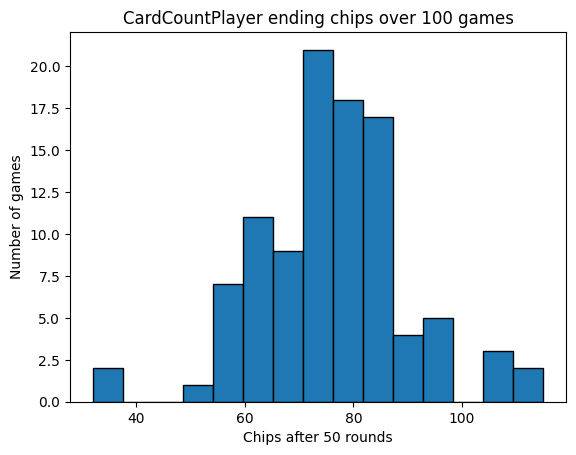

Mean ending chips:       75.84
Std of ending chips:     13.805593069477315
Mean total winnings:     -24.159999999999997
Average winnings/round:  -0.4831999999999999

P(net win):     0.05
P(net loss):    0.95
P(break even):  0.0


In [10]:
starting_chips    = 100
n_games           = 100
n_rounds          = 50
winnings_list     = list()
 
for g in range(n_games):
    game8 = Game(verbose=False)
    counter = CardCountPlayer("Counter", starting_chips, threshold=0)
    game8.add_player(counter)
    game8.add_player(SimplePlayer("DealerStyle1", starting_chips, 17))
    game8.add_player(SimplePlayer("DealerStyle2", starting_chips, 17))
    game8.add_player(SimplePlayer("DealerStyle3", starting_chips, 17))
    game8.play_game(n_rounds)
    winnings_list.append(counter.chips())
 
plt.hist(winnings_list, bins=15, edgecolor='black')
plt.xlabel("Chips after 50 rounds")
plt.ylabel("Number of games")
plt.title("CardCountPlayer ending chips over 100 games")
plt.show()
 
mean_chips         = np.mean(winnings_list)
std_chips          = np.std(winnings_list)
mean_winnings      = mean_chips - starting_chips
winnings_per_round = mean_winnings / n_rounds
 
print("Mean ending chips:      ", mean_chips)
print("Std of ending chips:    ", std_chips)
print("Mean total winnings:    ", mean_winnings)
print("Average winnings/round: ", winnings_per_round)
 
n_won  = sum(1 for w in winnings_list if w > starting_chips)
n_lost = sum(1 for w in winnings_list if w < starting_chips)
print()
print("P(net win):    ", n_won  / float(n_games))
print("P(net loss):   ", n_lost / float(n_games))
print("P(break even): ", (n_games - n_won - n_lost) / float(n_games))

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

threshold = -4  | mean chips: 89.44  | std: 14.71  | win/round: -0.2112
threshold = -2  | mean chips: 89.48  | std: 15.21  | win/round: -0.2104
threshold = 0  | mean chips: 75.72  | std: 14.01  | win/round: -0.4856
threshold = 2  | mean chips: 56.09  | std: 12.51  | win/round: -0.8782
threshold = 4  | mean chips: 40.97  | std: 11.77  | win/round: -1.1806


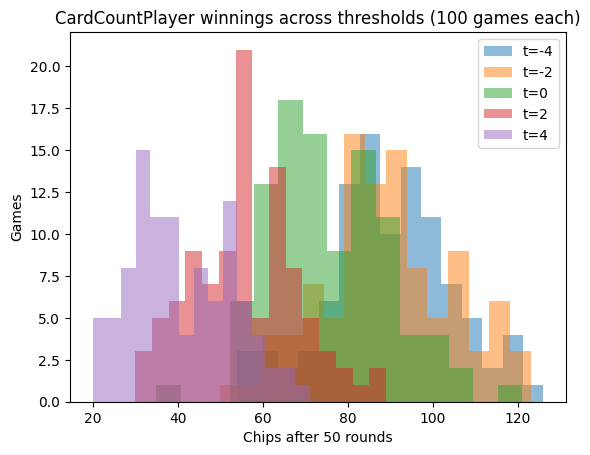

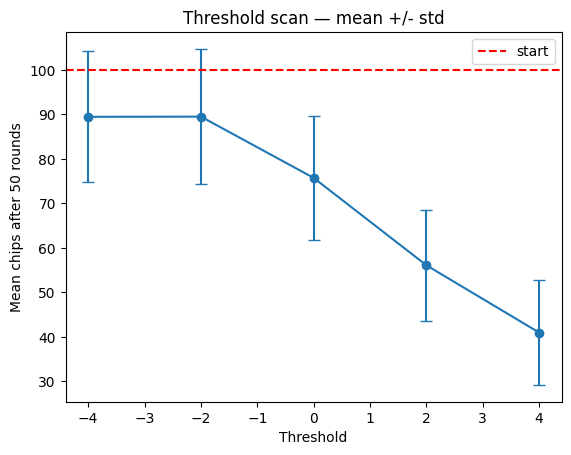

Best threshold: -2   mean chips: 89.48


In [11]:
starting_chips = 100
n_games        = 100
n_rounds       = 50
thresholds     = [-4, -2, 0, 2, 4]
mean_results   = list()
std_results    = list()
 
for thresh in thresholds:
    winnings_list = list()
    for g in range(n_games):
        game9 = Game(verbose=False)
        counter = CardCountPlayer("Counter", starting_chips, threshold=thresh)
        game9.add_player(counter)
        game9.add_player(SimplePlayer("DealerStyle1", starting_chips, 17))
        game9.add_player(SimplePlayer("DealerStyle2", starting_chips, 17))
        game9.add_player(SimplePlayer("DealerStyle3", starting_chips, 17))
        game9.play_game(n_rounds)
        winnings_list.append(counter.chips())
 
    mean_val = np.mean(winnings_list)
    std_val  = np.std(winnings_list)
    mean_results.append(mean_val)
    std_results.append(std_val)
 
    print("threshold =", thresh,
          " | mean chips:", round(mean_val, 2),
          " | std:", round(std_val, 2),
          " | win/round:", round((mean_val - starting_chips) / n_rounds, 4))
 
    plt.hist(winnings_list, bins=15, alpha=0.5, label="t=" + str(thresh))
 
plt.xlabel("Chips after 50 rounds")
plt.ylabel("Games")
plt.title("CardCountPlayer winnings across thresholds (100 games each)")
plt.legend()
plt.show()
 
plt.errorbar(thresholds, mean_results, yerr=std_results, fmt='o-', capsize=4)
plt.axhline(y=starting_chips, color='r', linestyle='--', label="start")
plt.xlabel("Threshold")
plt.ylabel("Mean chips after 50 rounds")
plt.title("Threshold scan — mean +/- std")
plt.legend()
plt.show()
 
best_idx = np.argmax(mean_results)
print("Best threshold:", thresholds[best_idx],
      "  mean chips:", round(mean_results[best_idx], 2))

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

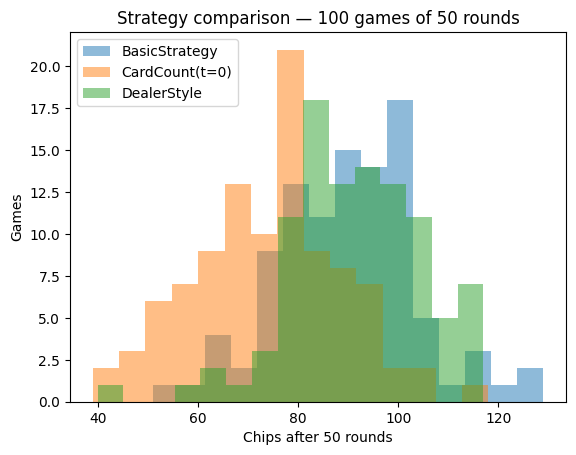

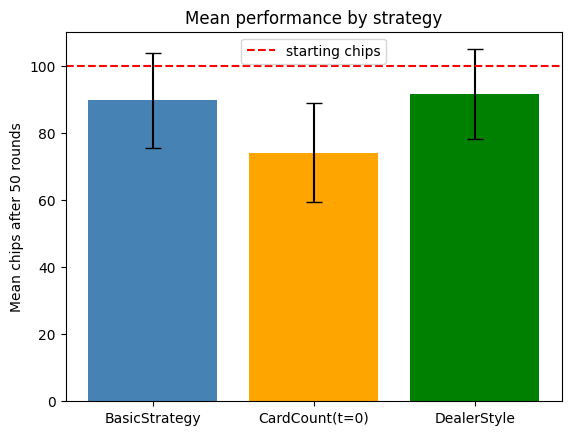

Strategy results (100 games, 50 rounds each):

BasicStrategy
  mean chips     : 89.77
  std            : 14.13
  winnings/round : -0.2046
  P(win)         : 0.22
  P(lose)        : 0.75

CardCount(t=0)
  mean chips     : 74.24
  std            : 14.9
  winnings/round : -0.5152
  P(win)         : 0.04
  P(lose)        : 0.95

DealerStyle
  mean chips     : 91.72
  std            : 13.33
  winnings/round : -0.1656
  P(win)         : 0.26
  P(lose)        : 0.73



In [12]:
# BasicStrategyPlayer: checks the dealer's visible card when the hand
# is 12-16. Dealer showing 2-6 means they are likely to bust so we
# stand and let them; dealer showing 7+ means we need to improve.
 
class BasicStrategyPlayer(Player):
 
    def __init__(self, name, chips=100):
        Player.__init__(self, name, chips)
 
    def play_hand(self, up_cards, down_card, seen_cards):
        full_hand = [down_card] + up_cards
        val       = hand_value(full_hand)
 
        if val >= 17:
            return False         # always stand 17+
        if val <= 11:
            return True          # can't bust on one more card
 
        # for 12-16 use the first up card in seen_cards as a proxy
        # for the dealer's visible card (the first face-up card dealt)
        if len(seen_cards) > 0:
            dealer_up_val = seen_cards[0].numerical_value()
            if 2 <= dealer_up_val <= 6:
                return False     # dealer weak — stand and let them bust
            else:
                return True      # dealer strong — we need to improve
 
        return val < 17
 
 
# compare all three strategies in the same game conditions
starting_chips = 100
n_games        = 100
n_rounds       = 50
 
strategies = {
    "BasicStrategy" : [],
    "CardCount(t=0)": [],
    "DealerStyle"   : []
}
 
for g in range(n_games):
    game10 = Game(verbose=False)
 
    basic        = BasicStrategyPlayer("BasicStrategy", starting_chips)
    counter      = CardCountPlayer("CardCount(t=0)", starting_chips, threshold=0)
    dealer_style = SimplePlayer("DealerStyle", starting_chips, 17)
 
    game10.add_player(basic)
    game10.add_player(counter)
    game10.add_player(dealer_style)
 
    game10.play_game(n_rounds)
 
    strategies["BasicStrategy"].append(basic.chips())
    strategies["CardCount(t=0)"].append(counter.chips())
    strategies["DealerStyle"].append(dealer_style.chips())
 
# overlaid histogram
for name, results in strategies.items():
    plt.hist(results, bins=15, alpha=0.5, label=name)
plt.xlabel("Chips after 50 rounds")
plt.ylabel("Games")
plt.title("Strategy comparison — 100 games of 50 rounds")
plt.legend()
plt.show()
 
# bar chart with error bars
names = list(strategies.keys())
means = [np.mean(strategies[n]) for n in names]
stds  = [np.std(strategies[n])  for n in names]
 
plt.bar(names, means, yerr=stds, capsize=6, color=['steelblue', 'orange', 'green'])
plt.axhline(y=starting_chips, color='r', linestyle='--', label="starting chips")
plt.ylabel("Mean chips after 50 rounds")
plt.title("Mean performance by strategy")
plt.legend()
plt.show()
 
print("Strategy results (100 games, 50 rounds each):")
print()
for name in names:
    results  = strategies[name]
    mean_val = np.mean(results)
    std_val  = np.std(results)
    wins     = sum(1 for r in results if r > starting_chips)
    losses   = sum(1 for r in results if r < starting_chips)
    print(name)
    print("  mean chips     :", round(mean_val, 2))
    print("  std            :", round(std_val, 2))
    print("  winnings/round :", round((mean_val - starting_chips) / n_rounds, 4))
    print("  P(win)         :", wins   / float(n_games))
    print("  P(lose)        :", losses / float(n_games))
    print()